In [1]:
import snntorch as snn
from snntorch import spikeplot as splt
from snntorch import spikegen

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import tonic

c:\Users\emiel\Documents\Study\Thesis\Thesis-Code\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
heidelberg_dataset_train = tonic.datasets.SHD(save_to='./data', train=True)
heidelberg_dataset_test = tonic.datasets.SHD(save_to='./data', train=False)

shd_test.h5.zip
1


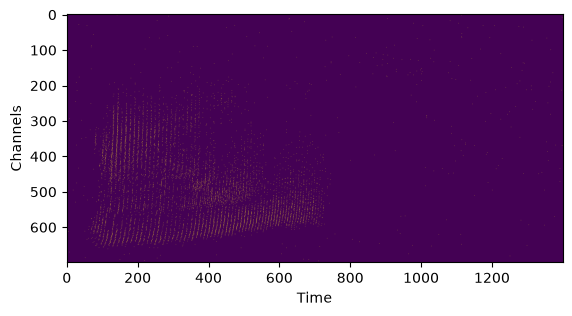

In [ ]:
events, targets = heidelberg_dataset_train[4389]

t = events['t']
x = events['x']
p = events['p']

# print(max(t))
# print(max(x))
# print(min(x))
print(min(p))

# print(targets)
tonic.utils.plot_event_grid(events)

In [59]:
max_t = 0
for events, target in heidelberg_dataset_train:
    max_t = max(max_t, events['t'].max())

print("Test:")
print(max_t, "µs =", max_t / 1e6, "s")

max_t = 0
for events, target in heidelberg_dataset_test:
    max_t = max(max_t, events['t'].max())

print("Train:")
print(max_t, "µs =", max_t / 1e6, "s")

Test:
1369140 µs = 1.36914 s
Train:
1169921 µs = 1.169921 s


In [67]:
import tonic
from torch.utils.data import DataLoader
from tonic import DiskCachedDataset
import tonic.transforms as transforms
import shutil

def get_SHD_dataloader(batch_size: int, time_window: float = 10000, train: bool = True, shuffle: bool = True, re_download: bool = False) -> DataLoader:
    train_extension = "train" if train else "test"
    if re_download:
        shutil.rmtree(f'./datasets/cache/SHD/{train_extension}', ignore_errors=True)
        shutil.rmtree(f'./datasets/data/SHD', ignore_errors=True)

    frame_transform = transforms.ToFrame(
        sensor_size=tonic.datasets.SHD.sensor_size,
        time_window=time_window,
        start_time=0,
    )
    dataset = tonic.datasets.SHD(
        save_to='./datasets/data', 
        train=train,
        transform=frame_transform,
    )
    cached_dataset = DiskCachedDataset(
        dataset,
        cache_path=f'./datasets/cache/SHD/{train_extension}'
    )
    return DataLoader(
        cached_dataset,
        batch_size=batch_size,
        collate_fn=tonic.collation.PadTensors(batch_first=False),
        shuffle=shuffle,
    )

In [72]:
SHD_trainloader = get_SHD_dataloader(
    batch_size=128,
    time_window=10000,
    train=True,
    shuffle=True,
    re_download=False,
)
print(SHD_trainloader.dataset.dataset.targets)
print(SHD_trainloader.dataset.dataset.sensor_size)
event_tensor, target = next(iter(SHD_trainloader))
print(target)
print(event_tensor.shape)
# print(event_tensor)

[]
(700, 1, 1)
tensor([12, 14, 11, 15,  3,  9, 12, 13, 13,  2,  8, 18, 13, 11,  2, 10,  6, 15,
         6,  6, 15, 17,  0,  1,  2, 17, 14, 19, 10, 19,  2,  3,  2, 19, 15, 11,
        18, 12,  1, 12, 11, 15,  6, 15,  5, 18,  5,  6, 14,  2, 16,  7,  7, 10,
         9, 14,  4, 19,  5, 12, 12, 10, 10, 16, 18,  8, 16,  4,  3,  7,  5, 10,
         4, 11, 15, 17,  3,  7, 15,  2, 12, 18,  4,  8,  3, 10, 11,  7,  3,  9,
        17,  5,  4, 10, 18,  4, 16, 19,  0,  9,  6,  7,  7,  2,  7,  9,  3, 11,
        11, 16, 17, 11, 11,  8, 19, 15,  1,  8,  7, 14, 14, 10, 15, 12, 16, 13,
        13, 10])
torch.Size([124, 128, 1, 700])


In [ ]:
dtype = torch.float
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

In [ ]:
class Net(nn.Module):
    def __init__(self, layers: list[int]):
        super().__init__()

        self.fc1 = nn.Linear(num_inputs, num_hidden)
        self.lif1 = snn.Leaky(beta=beta)
        self.fc2 = nn.Linear(num_hidden, num_outputs)
        self.lif2 = snn.Leaky(beta=beta)

    def forward(self, x):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()

        spk2_rec = []
        mem2_rec = []

        for step in range(num_steps):
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            spk2_rec.append(spk2)
            mem2_rec.append(mem2)

        return torch.stack(spk2_rec, dim=0), torch.stack(mem2_rec, dim=0)

net = Net().to(device)

In [ ]:
from torch import Tensor

class RecurrentLayer(nn.Module):
    def __init__(self, n_in: int, n_out: int, beta: float) -> None:
        super().__init__()

        self.fc = nn.Linear(n_in, n_out)
        self.lif = snn.Leaky(beta=beta)
        self.rc = nn.Linear(n_out, n_out)

        self.lif_mem = self.lif.init_leaky()
        self.rc_mem: Tensor = None

    def reset_mem(self) -> None:
        self.lif_mem = self.lif.init_leaky()
        self.rc_mem: Tensor = None

    def forward(self, x: Tensor) -> Tensor:
        if self.rc_mem is None:
            self.rc_mem = torch.zeros(x.shape[0], self.rc.out_features, device=x.device)     # init with random recurrent values on first forward pass

        currents = self.fc(x) + self.rc_mem
        spikes, self.lif_mem = self.lif(currents, self.lif_mem)
        self.rc_mem = self.rc(spikes)
        return spikes

class OutputLayer(nn.Module):
    def __init__(self, n_in: int, n_out: int, beta: float) -> None:
        super().__init__()

        self.fc = nn.Linear(n_in, n_out)
        self.lif = snn.Leaky(beta=beta)
        self.lif_mem = self.lif.init_leaky()

    def reset_mem(self) -> None:
        self.lif_mem = self.lif.init_leaky()

    def forward(self, x: Tensor) -> tuple[Tensor, Tensor]:
        currents = self.fc(x)
        spikes, self.lif_mem = self.lif(currents, self.lif_mem)
        return spikes, self.lif_mem

class SRNN(nn.Module):
    def __init__(self, n_in: int, ns_hidden: list[int], n_out: int, beta: float) -> None:
        super().__init__()

        layers = [n_in] + ns_hidden
        self.rec_layers = nn.ModuleList(
            [RecurrentLayer(a, b, beta) for a, b in zip(layers[:-1], layers[1:])]
        )
        self.out_layer = OutputLayer(ns_hidden[-1], n_out, beta)

    def reset_mems(self) -> None:
        for layer in self.rec_layers:
            layer.reset_mem()
        self.out_layer.reset_mem()

    def forward(self, x: Tensor) -> tuple[Tensor, Tensor]:
        for layer in self.rec_layers:
            x = layer(x)
        return self.out_layer(x)

srnn = SRNN(
    n_in=10,
    ns_hidden=[100, 200],
    n_out=5,
    beta=0.9,
)

In [ ]:
# Init network
num_inputs = 784
num_hidden = 1000
num_outputs = 10

layers = [700, 1000, 10]

beta = 0.99

fc1 = nn.Linear(num_inputs, num_hidden)
lif1 = snn.Leaky(beta=beta)

syn_exc, syn_inh, mem = lif2.init_alpha()
mem_rec = []
spk_rec = []